<a href="https://colab.research.google.com/github/HridhyaKP/Customer-Segmentation/blob/main/E_Commerce_Customer_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/online_retail.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/online_retail.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
df.head()

NameError: name 'df' is not defined

In [ ]:
df.shape

(187908, 8)

In [ ]:
df.info() #gives info of numeric values only. df.info(include="all") gives info of all columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.isnull().sum()   #to replace null values, mean or medium is used. Mean gets affected by outliers, so choose median.

,0
InvoiceNo,0
StockCode,0
Description,763
Quantity,1
InvoiceDate,1
UnitPrice,1
CustomerID,55729
Country,1


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,186305.000000,186305.000000,130577.000000
mean,9.262387,5.068195,15261.688215
std,249.056891,97.584901,1726.862579
min,-74215.000000,0.000000,12346.000000
25%,1.000000,1.250000,13802.000000
50%,3.000000,2.250000,15121.000000
75%,10.000000,4.210000,16788.000000
max,74215.000000,16888.020000,18283.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated(subset=['InvoiceNo', 'StockCode']).sum()

np.int64(3168)

In [ ]:
df[df.duplicated(subset=['InvoiceNo', 'StockCode'], keep=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom
483,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,3,2010-12-01 11:45:00,6.35,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
...,...,...,...,...,...,...,...,...
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541697,581538,21194,PINK HONEYCOMB PAPER FAN,1,2011-12-09 11:34:00,0.65,14446.0,United Kingdom
541698,581538,35004B,SET OF 3 BLACK FLYING DUCKS,1,2011-12-09 11:34:00,5.45,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [ ]:
df.loc[:, 'InvoiceNo'] = df['InvoiceNo'].astype(str)

In [ ]:
df[df['InvoiceNo'].str.startswith('C')].shape

(3367, 8)

In [ ]:
df[df['Quantity'] <= 0].shape

(3962, 8)

In [ ]:
df[df['UnitPrice'] <= 0].shape

(1130, 8)

In [ ]:
df_clean = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0) &
    (~df['InvoiceNo'].str.startswith('C'))
]

In [ ]:
df_clean.shape
df_clean.describe()

,Quantity,UnitPrice,CustomerID
count,181808.000000,181808.000000,127357.000000
mean,10.349253,4.195585,15269.735492
std,178.528002,41.490091,1726.794825
min,1.000000,0.001000,12346.000000
25%,1.000000,1.250000,13824.000000
50%,3.000000,2.250000,15140.000000
75%,10.000000,4.210000,16795.000000
max,74215.000000,13541.330000,18283.000000


In [ ]:
df_clean['CustomerID'].isnull().sum()

np.int64(54451)

In [ ]:
df_clean = df_clean.dropna(subset=['CustomerID'])

In [ ]:
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [ ]:
df_clean['CustomerID'].isnull().sum()
df_clean['CustomerID'].dtype

dtype('int64')

In [ ]:
df_clean = df_clean.copy()

In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(
    df_clean['InvoiceDate'],
    errors='coerce',
    infer_datetime_format=True
)

/tmp/ipython-input-4072612194.py:1: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_clean['InvoiceDate'] = pd.to_datetime(


In [ ]:
df_clean['InvoiceDate'].dtype

dtype('<M8[ns]')

In [ ]:
df_clean['InvoiceDate'].isnull().sum()

np.int64(0)

In [ ]:
df_clean['InvoiceDate'].head()

,InvoiceDate
0,2010-12-01 08:26:00
1,2010-12-01 08:26:00
2,2010-12-01 08:26:00
3,2010-12-01 08:26:00
4,2010-12-01 08:26:00


In [ ]:
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [ ]:
df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6.0,2.55,15.30
1,6.0,3.39,20.34
2,8.0,2.75,22.00
3,6.0,3.39,20.34
4,6.0,3.39,20.34


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127357 entries, 0 to 187906
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    127357 non-null  object        
 1   StockCode    127357 non-null  object        
 2   Description  127357 non-null  object        
 3   Quantity     127357 non-null  float64       
 4   InvoiceDate  127357 non-null  datetime64[ns]
 5   UnitPrice    127357 non-null  float64       
 6   CustomerID   127357 non-null  int64         
 7   Country      127357 non-null  object        
 8   TotalAmount  127357 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 9.7+ MB


In [ ]:
import datetime as dt

snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
snapshot_date

Timestamp('2011-05-13 18:13:00')

In [ ]:
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                   # Frequency
    'TotalAmount': 'sum'                                      # Monetary
})

In [ ]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [ ]:
rfm.head()
rfm.describe()

,Recency,Frequency,Monetary
count,2572.000000,2572.000000,2572.000000
mean,58.310264,2.525661,1136.985902
std,47.308477,3.668238,3756.989546
min,1.000000,1.000000,3.750000
25%,22.000000,1.000000,235.130000
50%,46.000000,1.000000,440.050000
75%,87.000000,3.000000,985.302500
max,163.000000,81.000000,99607.840000


In [ ]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

In [ ]:
import pandas as pd

rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary']
)

rfm_scaled_df.mean()
rfm_scaled_df.std()

,0
Recency,1.000194
Frequency,1.000194
Monetary,1.000194


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

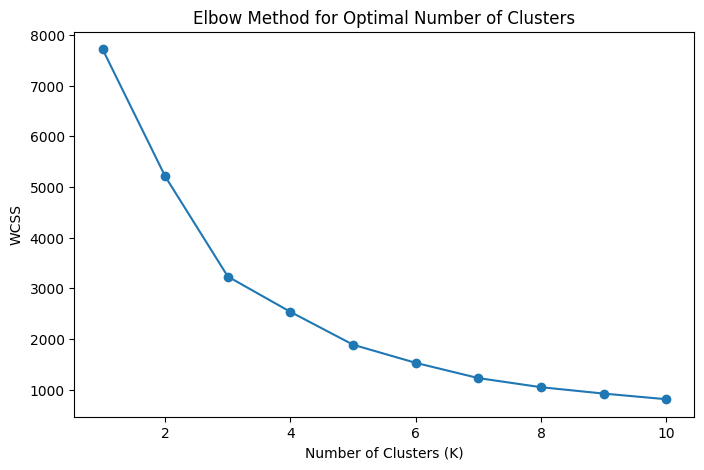

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,115,1,77183.60,1
12347,36,3,1823.43,0
12348,38,3,1487.24,0
12350,100,1,334.40,2
12352,52,5,1561.81,0


In [ ]:
rfm['Cluster'].value_counts()

,count
Cluster,
0,1567
2,779
3,206
1,20


In [ ]:
rfm.groupby('Cluster').mean()

,Recency,Frequency,Monetary
Cluster,,,
0,33.797064,2.012125,718.303325
1,14.850000,26.000000,34480.258000
2,119.681643,1.284981,421.910116
3,16.917476,8.844660,3788.705291


In [ ]:
cluster_names = {
    0: 'Potential Loyalists',
    1: 'High-Value Customers',
    2: 'At-Risk / Low-Value',
    3: 'Loyal Customers'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_names)
rfm[['Cluster', 'Segment']].head()

,Cluster,Segment
CustomerID,,
12346,1,High-Value Customers
12347,0,Potential Loyalists
12348,0,Potential Loyalists
12350,2,At-Risk / Low-Value
12352,0,Potential Loyalists


In [ ]:
rfm_final = rfm.reset_index()

NameError: name 'rfm' is not defined

In [ ]:
rfm_final.to_csv('customer_segmentation_rfm.csv', index=False)